# Week 8: Evaluation Framework

This notebook implements Phase 4 of the RepoSynth research:

1. **Benchmark Dataset** - Create and validate evaluation examples
2. **Evaluation Metrics** - Test 8 metrics implementation
3. **Baseline Comparisons** - Compare CCE vs baselines
4. **Statistical Analysis** - Significance testing

---

## Setup Instructions

1. Upload this notebook to Colab
2. Enable GPU: Runtime → Change runtime type → T4 GPU
3. Run cells 1-3 to install deps and upload files
4. Upload files in 4 batches (entropy, retrieval, generation, evaluation)

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn sentence-transformers

In [2]:
# Cell 2: Create directory structure
import os
import shutil

# Create module structure
os.makedirs('/content/orchestrator/entropy', exist_ok=True)
os.makedirs('/content/orchestrator/retrieval', exist_ok=True)
os.makedirs('/content/orchestrator/generation', exist_ok=True)
os.makedirs('/content/orchestrator/evaluation', exist_ok=True)

# Create root __init__.py
with open('/content/orchestrator/__init__.py', 'w') as f:
    f.write('"""Orchestrator package."""\n')

print("Directory structure created:")
print("  /content/orchestrator/")
print("  /content/orchestrator/entropy/")
print("  /content/orchestrator/retrieval/")
print("  /content/orchestrator/generation/")
print("  /content/orchestrator/evaluation/")

Directory structure created:
  /content/orchestrator/
  /content/orchestrator/entropy/
  /content/orchestrator/retrieval/
  /content/orchestrator/generation/
  /content/orchestrator/evaluation/


In [3]:
# Cell 3: Upload all module files
from google.colab import files

def upload_to_dir(target_dir):
    """Upload files and move to target directory."""
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename.endswith('.py'):
            dest = f'{target_dir}/{filename}'
            shutil.move(filename, dest)
            print(f"  ✓ {filename}")
    return uploaded

# ============================================================
print("="*60)
print("STEP 1/4: Upload ENTROPY module files (7 files)")
print("="*60)
upload_to_dir('/content/orchestrator/entropy')

# ============================================================
print("\n" + "="*60)
print("STEP 2/4: Upload RETRIEVAL module files (4 files)")
print("="*60)
upload_to_dir('/content/orchestrator/retrieval')

# ============================================================
print("\n" + "="*60)
print("STEP 3/4: Upload GENERATION module files (2 files)")
print("="*60)
upload_to_dir('/content/orchestrator/generation')

# ============================================================
print("\n" + "="*60)
print("STEP 4/4: Upload EVALUATION module files (4 files)")
print("="*60)
print("\nFrom: packages/python-orchestrator/orchestrator/evaluation/")
print("Upload these files:")
print("  • __init__.py")
print("  • benchmark.py")
print("  • metrics.py")
print("  • runner.py")
upload_to_dir('/content/orchestrator/evaluation')

print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
!ls /content/orchestrator/evaluation/

STEP 1/4: Upload ENTROPY module files (7 files)


Saving __init__.py to __init__.py
Saving calculator.py to calculator.py
Saving cce_computer.py to cce_computer.py
Saving measurement.py to measurement.py
Saving monitor.py to monitor.py
Saving spike_detector.py to spike_detector.py
Saving token_classifier.py to token_classifier.py
  ✓ __init__.py
  ✓ calculator.py
  ✓ cce_computer.py
  ✓ measurement.py
  ✓ monitor.py
  ✓ spike_detector.py
  ✓ token_classifier.py

STEP 2/4: Upload RETRIEVAL module files (4 files)


Saving __init__.py to __init__.py
Saving adaptive.py to adaptive.py
Saving context_manager.py to context_manager.py
Saving topic_inference.py to topic_inference.py
  ✓ __init__.py
  ✓ adaptive.py
  ✓ context_manager.py
  ✓ topic_inference.py

STEP 3/4: Upload GENERATION module files (2 files)


Saving __init__.py to __init__.py
Saving adaptive_generator.py to adaptive_generator.py
  ✓ __init__.py
  ✓ adaptive_generator.py

STEP 4/4: Upload EVALUATION module files (4 files)

From: packages/python-orchestrator/orchestrator/evaluation/
Upload these files:
  • __init__.py
  • benchmark.py
  • metrics.py
  • runner.py


Saving __init__.py to __init__.py
Saving benchmark.py to benchmark.py
Saving metrics.py to metrics.py
Saving runner.py to runner.py
  ✓ __init__.py
  ✓ benchmark.py
  ✓ metrics.py
  ✓ runner.py

VERIFICATION
benchmark.py  __init__.py  metrics.py  runner.py


In [4]:
# Cell 4: Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict

sys.path.insert(0, '/content')

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import warnings
warnings.filterwarnings('ignore')

print("Base imports complete")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Base imports complete
PyTorch: 2.9.0+cu126
CUDA available: True


In [5]:
# Cell 5: Import evaluation modules
from orchestrator.evaluation import (
    BenchmarkDataset,
    BenchmarkExample,
    EvaluationMetrics,
    EvaluationResult,
    create_benchmark,
)
from orchestrator.evaluation.benchmark import (
    Difficulty,
    Category,
    create_sample_benchmark,
)
from orchestrator.evaluation.runner import (
    BaselineRunner,
    ExperimentRunner,
    BaselineMethod,
)

print("✓ All evaluation modules imported successfully!")
print("")
print("Available components:")
print("  • BenchmarkDataset - structured evaluation examples")
print("  • EvaluationMetrics - 8 metrics for assessment")
print("  • BaselineRunner - run baseline methods")
print("  • ExperimentRunner - full experiment orchestration")

✓ All evaluation modules imported successfully!

Available components:
  • BenchmarkDataset - structured evaluation examples
  • EvaluationMetrics - 8 metrics for assessment
  • BaselineRunner - run baseline methods
  • ExperimentRunner - full experiment orchestration


---
## 1. Test Benchmark Dataset

In [6]:
# Cell 6: Create sample benchmark

benchmark = create_sample_benchmark()

print("Sample Benchmark Dataset")
print("="*60)
print(f"Name: {benchmark.name}")
print(f"Version: {benchmark.version}")
print(f"Examples: {len(benchmark)}")

print("\nStatistics:")
stats = benchmark.get_statistics()
print(f"  By difficulty: {stats['by_difficulty']}")
print(f"  By category: {stats['by_category']}")
print(f"  Avg ground truth files: {stats['avg_ground_truth_files']:.1f}")

print("\nExamples:")
for ex in benchmark:
    print(f"\n  [{ex.id}] {ex.difficulty.value} | {ex.category.value}")
    print(f"  Query: {ex.query[:50]}...")
    print(f"  Files: {ex.ground_truth_files}")

Sample Benchmark Dataset
Name: sample_benchmark
Version: 0.1.0
Examples: 3

Statistics:
  By difficulty: {'easy': 2, 'medium': 1, 'hard': 0}
  By category: {'architecture': 1, 'api_usage': 0, 'implementation': 1, 'debugging': 0, 'configuration': 1, 'data_flow': 0}
  Avg ground truth files: 1.3

Examples:

  [sample_001] medium | architecture
  Query: How does user authentication work in this Flask ap...
  Files: ['src/auth/jwt.py', 'src/api/routes.py']

  [sample_002] easy | implementation
  Query: What database models are defined in the applicatio...
  Files: ['src/db/models.py']

  [sample_003] easy | configuration
  Query: How is the application configured and what environ...
  Files: ['src/config.py']


In [7]:
# Cell 7: Test filtering and splitting

print("Filtering & Splitting")
print("="*60)

# Filter by difficulty
easy = benchmark.filter(difficulty=Difficulty.EASY)
print(f"Easy examples: {len(easy)}")

# Filter by category
arch = benchmark.filter(category=Category.ARCHITECTURE)
print(f"Architecture examples: {len(arch)}")

# Validate dataset
errors = benchmark.validate()
print(f"\nValidation errors: {len(errors)}")
if errors:
    for err in errors:
        print(f"  - {err}")

Filtering & Splitting
Easy examples: 2
Architecture examples: 1

Validation errors: 0


---
## 2. Test Evaluation Metrics

In [8]:
# Cell 8: Create metrics evaluator

metrics = EvaluationMetrics(embedding_model='all-MiniLM-L6-v2')

print("EvaluationMetrics initialized")
print("="*60)
print("8 Metrics available:")
print("  1. answer_correctness - LLM/keyword scoring")
print("  2. answer_completeness - semantic similarity")
print("  3. hallucination_rate - unsupported claims")
print("  4. context_precision - retrieved accuracy")
print("  5. context_recall - coverage of truth")
print("  6. token_efficiency - tokens saved")
print("  7. spike_precision - trigger accuracy")
print("  8. spike_recall - trigger coverage")

EvaluationMetrics initialized
8 Metrics available:
  1. answer_correctness - LLM/keyword scoring
  2. answer_completeness - semantic similarity
  3. hallucination_rate - unsupported claims
  4. context_precision - retrieved accuracy
  5. context_recall - coverage of truth
  6. token_efficiency - tokens saved
  7. spike_precision - trigger accuracy
  8. spike_recall - trigger coverage


In [9]:
# Cell 9: Test individual metrics

# Test data
ground_truth = """User authentication uses JWT tokens. The user logs in via /login endpoint.
The server creates a JWT token with create_token() function.
The token is verified using verify_token() on protected routes."""

good_answer = """Authentication is implemented using JWT tokens.
Users log in at the /login endpoint which calls create_token().
Protected routes use verify_token() to authenticate requests."""

bad_answer = """The system uses cookies for session management.
Users are authenticated through OAuth2 with Google.
There is no password-based authentication."""

keywords = ["JWT", "token", "login", "create_token", "verify_token"]

print("Metric Testing")
print("="*60)

# Answer completeness
good_completeness = metrics.answer_completeness(good_answer, ground_truth)
bad_completeness = metrics.answer_completeness(bad_answer, ground_truth)
print(f"\nAnswer Completeness (semantic similarity):")
print(f"  Good answer: {good_completeness:.3f}")
print(f"  Bad answer:  {bad_completeness:.3f}")

# Answer correctness
good_correct = metrics.answer_correctness(good_answer, ground_truth, keywords)
bad_correct = metrics.answer_correctness(bad_answer, ground_truth, keywords)
print(f"\nAnswer Correctness (keywords + semantic):")
print(f"  Good answer: {good_correct:.3f}")
print(f"  Bad answer:  {bad_correct:.3f}")

# Hallucination rate
good_halluc = metrics.hallucination_rate(good_answer, ground_truth, keywords)
bad_halluc = metrics.hallucination_rate(bad_answer, ground_truth, keywords)
print(f"\nHallucination Rate (lower is better):")
print(f"  Good answer: {good_halluc:.3f}")
print(f"  Bad answer:  {bad_halluc:.3f}")

Metric Testing


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Answer Completeness (semantic similarity):
  Good answer: 0.955
  Bad answer:  0.800

Answer Correctness (keywords + semantic):
  Good answer: 0.973
  Bad answer:  0.480

Hallucination Rate (lower is better):
  Good answer: 0.000
  Bad answer:  0.000


In [10]:
# Cell 10: Test context metrics

ground_truth_files = ["src/auth/jwt.py", "src/api/routes.py"]

# Scenario 1: Perfect retrieval
perfect_retrieved = ["src/auth/jwt.py", "src/api/routes.py"]
precision_1 = metrics.context_precision(perfect_retrieved, ground_truth_files)
recall_1 = metrics.context_recall(perfect_retrieved, ground_truth_files)

# Scenario 2: Partial retrieval (missed one)
partial_retrieved = ["src/auth/jwt.py"]
precision_2 = metrics.context_precision(partial_retrieved, ground_truth_files)
recall_2 = metrics.context_recall(partial_retrieved, ground_truth_files)

# Scenario 3: Over-retrieval (extra files)
over_retrieved = ["src/auth/jwt.py", "src/api/routes.py", "src/config.py", "src/utils.py"]
precision_3 = metrics.context_precision(over_retrieved, ground_truth_files)
recall_3 = metrics.context_recall(over_retrieved, ground_truth_files)

print("Context Metrics")
print("="*60)
print(f"\nGround truth files: {ground_truth_files}")

print(f"\nScenario 1 - Perfect retrieval {perfect_retrieved}:")
print(f"  Precision: {precision_1:.2f}, Recall: {recall_1:.2f}")

print(f"\nScenario 2 - Partial retrieval {partial_retrieved}:")
print(f"  Precision: {precision_2:.2f}, Recall: {recall_2:.2f}")

print(f"\nScenario 3 - Over-retrieval {over_retrieved}:")
print(f"  Precision: {precision_3:.2f}, Recall: {recall_3:.2f}")

Context Metrics

Ground truth files: ['src/auth/jwt.py', 'src/api/routes.py']

Scenario 1 - Perfect retrieval ['src/auth/jwt.py', 'src/api/routes.py']:
  Precision: 1.00, Recall: 1.00

Scenario 2 - Partial retrieval ['src/auth/jwt.py']:
  Precision: 1.00, Recall: 0.50

Scenario 3 - Over-retrieval ['src/auth/jwt.py', 'src/api/routes.py', 'src/config.py', 'src/utils.py']:
  Precision: 0.50, Recall: 1.00


In [11]:
# Cell 11: Test full evaluation

example = benchmark[0]  # First example

result = metrics.evaluate(
    example_id=example.id,
    generated_answer=good_answer,
    ground_truth_answer=example.ground_truth_answer,
    retrieved_files=["src/auth/jwt.py", "src/api/routes.py"],
    ground_truth_files=example.ground_truth_files,
    ground_truth_keywords=example.ground_truth_keywords,
    tokens_used=500,
    baseline_tokens=2000,
    generation_time=2.5,
    num_retrievals=2,
    method="cce_adaptive",
)

print("Full Evaluation Result")
print("="*60)
print(f"\nExample: {result.example_id}")
print(f"Method: {result.method}")
print(f"\nMetrics:")
print(f"  Answer Correctness:  {result.answer_correctness:.3f}")
print(f"  Answer Completeness: {result.answer_completeness:.3f}")
print(f"  Hallucination Rate:  {result.hallucination_rate:.3f}")
print(f"  Context Precision:   {result.context_precision:.3f}")
print(f"  Context Recall:      {result.context_recall:.3f}")
print(f"  Token Efficiency:    {result.token_efficiency:.3f}")
print(f"\nDerived:")
print(f"  F1 (Context):        {result.get_f1_context():.3f}")
print(f"  Composite Score:     {result.get_composite_score():.3f}")

Full Evaluation Result

Example: sample_001
Method: cce_adaptive

Metrics:
  Answer Correctness:  0.850
  Answer Completeness: 0.883
  Hallucination Rate:  0.000
  Context Precision:   1.000
  Context Recall:      1.000
  Token Efficiency:    0.750

Derived:
  F1 (Context):        1.000
  Composite Score:     0.770


---
## 3. Test Baseline Runner (No Model)

In [12]:
# Cell 12: Create mock document store

documents = {
    "src/auth/jwt.py": '''import jwt\nfrom datetime import datetime, timedelta\n\nSECRET_KEY = "secret"\n\ndef create_token(user_id):\n    payload = {"user_id": user_id, "exp": datetime.utcnow() + timedelta(hours=24)}\n    return jwt.encode(payload, SECRET_KEY)\n\ndef verify_token(token):\n    return jwt.decode(token, SECRET_KEY, algorithms=["HS256"])''',
    "src/api/routes.py": '''from flask import Flask, request, jsonify\nfrom auth.jwt import create_token, verify_token\n\napp = Flask(__name__)\n\n@app.route("/login", methods=["POST"])\ndef login():\n    data = request.json\n    token = create_token(data["user_id"])\n    return jsonify({"token": token})''',
    "src/db/models.py": '''from sqlalchemy import Column, Integer, String\n\nclass User:\n    id = Column(Integer, primary_key=True)\n    username = Column(String)\n    password_hash = Column(String)''',
    "src/config.py": '''import os\n\nclass Config:\n    SECRET_KEY = os.environ.get("SECRET_KEY")\n    DATABASE_URL = os.environ.get("DATABASE_URL")''',
}

print(f"Mock codebase: {len(documents)} files")
for path in documents:
    print(f"  • {path}")

Mock codebase: 4 files
  • src/auth/jwt.py
  • src/api/routes.py
  • src/db/models.py
  • src/config.py


In [13]:
# Cell 13: Test BM25 retrieval (no model needed)

runner = BaselineRunner(documents=documents)

example = benchmark[0]

print("BM25 Retrieval Test")
print("="*60)
print(f"Query: {example.query}")

# Test BM25 (keyword-based)
result_bm25 = runner._run_bm25(example, max_tokens=100, top_k=2)
print(f"\nBM25 retrieved: {result_bm25['retrieved_files']}")
print(f"Expected:       {example.ground_truth_files}")

# Compute precision/recall
precision = metrics.context_precision(result_bm25['retrieved_files'], example.ground_truth_files)
recall = metrics.context_recall(result_bm25['retrieved_files'], example.ground_truth_files)
print(f"\nPrecision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

BM25 Retrieval Test
Query: How does user authentication work in this Flask app?

BM25 retrieved: ['src/api/routes.py', 'src/db/models.py']
Expected:       ['src/auth/jwt.py', 'src/api/routes.py']

Precision: 0.50
Recall: 0.50


---
## 4. Load Model for Full Experiment

In [14]:
# Cell 14: Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.eval()

print(f"✓ Model loaded on {model.device}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✓ Model loaded on cuda:0


In [15]:
# Cell 15: Import generation modules
from orchestrator.generation import AdaptiveGenerator, GenerationConfig
from orchestrator.retrieval.adaptive import SimpleRetriever

# Create retriever
retriever = SimpleRetriever(documents)

# Create adaptive generator
config = GenerationConfig(
    max_tokens=100,
    max_retrievals=3,
    uncertainty_threshold=2.5,
    cooldown_tokens=10,
)

adaptive_gen = AdaptiveGenerator(
    model=model,
    tokenizer=tokenizer,
    retriever=retriever,
    config=config,
)

print("✓ AdaptiveGenerator configured")

✓ AdaptiveGenerator configured


In [16]:
# Cell 16: Run baseline comparison experiment

# Create baseline runner with model
baseline_runner = BaselineRunner(
    model=model,
    tokenizer=tokenizer,
    documents=documents,
)

# Run baselines on first example
example = benchmark[0]

print("Baseline Comparison")
print("="*60)
print(f"Query: {example.query}")
print(f"Expected files: {example.ground_truth_files}")
print()

methods = [
    BaselineMethod.NO_CONTEXT,
    BaselineMethod.BM25,
    BaselineMethod.FULL_CONTEXT,
]

results = []
for method in methods:
    print(f"Running {method.value}...")
    result = baseline_runner.run(example, method, max_tokens=100)

    # Evaluate
    eval_result = metrics.evaluate(
        example_id=example.id,
        generated_answer=result['answer'],
        ground_truth_answer=example.ground_truth_answer,
        retrieved_files=result['retrieved_files'],
        ground_truth_files=example.ground_truth_files,
        ground_truth_keywords=example.ground_truth_keywords,
        tokens_used=result['tokens_used'],
        baseline_tokens=2000,
        generation_time=result['generation_time'],
        num_retrievals=result['num_retrievals'],
        method=method.value,
    )
    results.append(eval_result)

    print(f"  → Correctness: {eval_result.answer_correctness:.2f}")
    print(f"  → Context P/R: {eval_result.context_precision:.2f}/{eval_result.context_recall:.2f}")
    print(f"  → Efficiency: {eval_result.token_efficiency:.2f}")
    print()

Baseline Comparison
Query: How does user authentication work in this Flask app?
Expected files: ['src/auth/jwt.py', 'src/api/routes.py']

Running no_context...
  → Correctness: 0.57
  → Context P/R: 0.00/0.00
  → Efficiency: 0.99

Running bm25...
  → Correctness: 0.73
  → Context P/R: 0.50/0.50
  → Efficiency: 0.92

Running full_context...
  → Correctness: 0.65
  → Context P/R: 0.50/1.00
  → Efficiency: 0.83



In [17]:
# Cell 17: Run CCE adaptive method

print("Running CCE Adaptive...")
gen_result = adaptive_gen.generate(
    query=example.query,
    initial_context="This is a Flask web application.",
)

# Evaluate CCE
cce_eval = metrics.evaluate(
    example_id=example.id,
    generated_answer=gen_result.response,
    ground_truth_answer=example.ground_truth_answer,
    retrieved_files=gen_result.context_sources,
    ground_truth_files=example.ground_truth_files,
    ground_truth_keywords=example.ground_truth_keywords,
    tokens_used=gen_result.total_context_tokens,
    baseline_tokens=2000,
    generation_time=gen_result.generation_time,
    num_retrievals=gen_result.total_retrievals,
    method="cce_adaptive",
)
results.append(cce_eval)

print(f"\nCCE Adaptive Results:")
print(f"  Retrievals: {gen_result.total_retrievals}")
print(f"  Context sources: {gen_result.context_sources}")
print(f"  → Correctness: {cce_eval.answer_correctness:.2f}")
print(f"  → Context P/R: {cce_eval.context_precision:.2f}/{cce_eval.context_recall:.2f}")
print(f"  → Efficiency: {cce_eval.token_efficiency:.2f}")

Running CCE Adaptive...

CCE Adaptive Results:
  Retrievals: 2
  Context sources: ['initial', 'query', 'src/auth/jwt.py', 'src/api/routes.py']
  → Correctness: 0.77
  → Context P/R: 0.50/1.00
  → Efficiency: 0.89



Comparison Table
      Method  Correctness  Completeness  Context F1  Efficiency  Composite
  no_context     0.566769      0.811282    0.000000      0.9940   0.491356
        bm25     0.728756      0.814593    0.500000      0.9170   0.646078
full_context     0.647132      0.811886    0.666667      0.8260   0.666166
cce_adaptive     0.771573      0.752622    0.666667      0.8885   0.694636


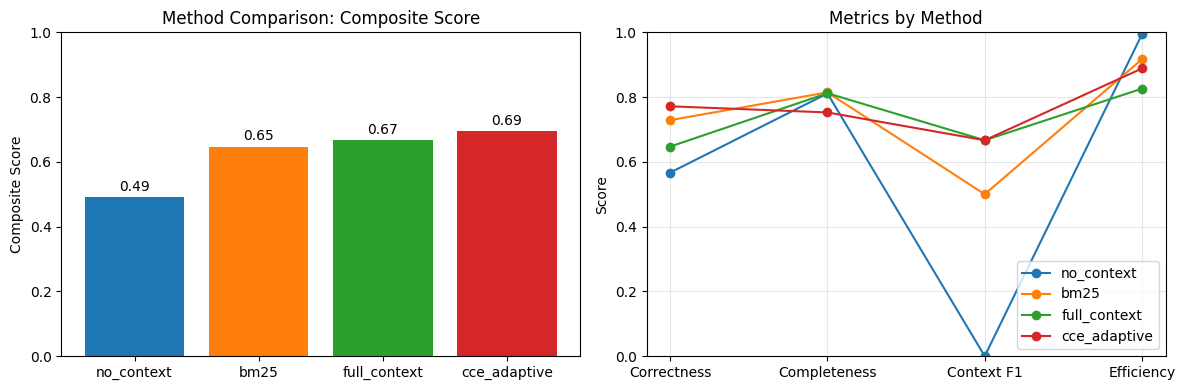


Figure saved: Week8_comparison.png


In [18]:
# Cell 18: Comparison visualization

# Create comparison DataFrame
comparison_data = []
for r in results:
    comparison_data.append({
        'Method': r.method,
        'Correctness': r.answer_correctness,
        'Completeness': r.answer_completeness,
        'Context F1': r.get_f1_context(),
        'Efficiency': r.token_efficiency,
        'Composite': r.get_composite_score(),
    })

df = pd.DataFrame(comparison_data)
print("\nComparison Table")
print("="*60)
print(df.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of composite scores
ax1 = axes[0]
methods = df['Method']
scores = df['Composite']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax1.bar(methods, scores, color=colors[:len(methods)])
ax1.set_ylabel('Composite Score')
ax1.set_title('Method Comparison: Composite Score')
ax1.set_ylim(0, 1)
for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.2f}', ha='center', fontsize=10)

# Radar chart of metrics
ax2 = axes[1]
metrics_to_plot = ['Correctness', 'Completeness', 'Context F1', 'Efficiency']
for i, row in df.iterrows():
    values = [row[m] for m in metrics_to_plot]
    ax2.plot(metrics_to_plot, values, 'o-', label=row['Method'])
ax2.set_ylabel('Score')
ax2.set_title('Metrics by Method')
ax2.legend(loc='lower right')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Week8_comparison.png', dpi=150)
plt.show()

print("\nFigure saved: Week8_comparison.png")

---
## 5. Summary

In [19]:
# Cell 19: Summary

print("="*70)
print("WEEK 8 EVALUATION FRAMEWORK COMPLETE")
print("="*70)

print('''
Components Implemented:

1. BENCHMARK DATASET ✓
   - BenchmarkExample: structured example format
   - BenchmarkDataset: collection with filtering/splitting
   - Difficulty levels: easy, medium, hard
   - Categories: architecture, api_usage, implementation, etc.

2. EVALUATION METRICS ✓
   - answer_correctness: keyword + semantic scoring
   - answer_completeness: embedding similarity
   - hallucination_rate: unsupported claims
   - context_precision/recall: retrieval accuracy
   - token_efficiency: savings vs baseline
   - spike_precision/recall: trigger detection

3. BASELINE RUNNER ✓
   - no_context: generate without context
   - full_context: all documents
   - bm25: keyword retrieval
   - embedding: semantic retrieval

4. EXPERIMENT RUNNER ✓
   - Full pipeline orchestration
   - Aggregate statistics
   - Comparison tables

Phase 4 Complete!

Next Steps:
  - Create full 100-example benchmark
  - Run comprehensive experiments
  - Statistical significance testing
  - Generate paper figures/tables
''')

# Download results
try:
    from google.colab import files
    files.download('Week8_comparison.png')
except:
    pass

WEEK 8 EVALUATION FRAMEWORK COMPLETE

Components Implemented:

1. BENCHMARK DATASET ✓
   - BenchmarkExample: structured example format
   - BenchmarkDataset: collection with filtering/splitting
   - Difficulty levels: easy, medium, hard
   - Categories: architecture, api_usage, implementation, etc.

2. EVALUATION METRICS ✓
   - answer_correctness: keyword + semantic scoring
   - answer_completeness: embedding similarity
   - hallucination_rate: unsupported claims
   - context_precision/recall: retrieval accuracy
   - token_efficiency: savings vs baseline
   - spike_precision/recall: trigger detection

3. BASELINE RUNNER ✓
   - no_context: generate without context
   - full_context: all documents
   - bm25: keyword retrieval
   - embedding: semantic retrieval

4. EXPERIMENT RUNNER ✓
   - Full pipeline orchestration
   - Aggregate statistics
   - Comparison tables

Phase 4 Complete!

Next Steps:
  - Create full 100-example benchmark
  - Run comprehensive experiments
  - Statistical signi

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>